# linear regression practice

## 1.Imports

### What this does
Imports three tools from **scikit-learn**:

- `load_diabetes` (from `sklearn.datasets`) — loads a built-in sample dataset
- `LinearRegression` (from `sklearn.linear_model`) — the model we'll train
- `train_test_split` (from `sklearn.model_selection`) — splits data into training and testing portions

### Why / When
These are needed before anything else — you always import the tools you need at the top of a notebook, before using them below.

In [1]:

from sklearn.datasets import load_diabetes
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split

## 2. Load the dataset

### What this does
```python
data = load_diabetes(as_frame=True)
df = data.frame
```

- `load_diabetes(as_frame=True)` loads scikit-learn's built-in diabetes dataset and asks it to return the data as **pandas** objects (DataFrame/Series) instead of plain NumPy arrays.
- The result, `data`, is a **Bunch** — a container object that bundles several related pieces together: `data.data` (features only), `data.target` (target only), `data.frame` (features + target combined), `data.feature_names`, `data.DESCR`, etc. You can access any of these either with brackets (`data['frame']`) or dot-notation (`data.frame`).
- `df = data.frame` pulls out the combined table (all 10 features + the `target` column, 11 columns total) and stores it as `df` — a clean `pandas.DataFrame` ready for the rest of the workflow.

### Why
`as_frame=True` matters because it attaches proper column names (`age`, `sex`, `bmi`, `bp`, `s1`...`s6`, `target`) to the data, which is needed for the DataFrame-style selection used later (`df[['bmi']]`).

### Output
Displays the full 442-row × 11-column DataFrame — every patient's 10 features plus their `target` value (a measure of disease progression).

In [2]:
data = load_diabetes(as_frame=True)
df = data.frame
df

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,target
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646,151.0
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204,75.0
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930,141.0
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362,206.0
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641,135.0
...,...,...,...,...,...,...,...,...,...,...,...
437,0.041708,0.050680,0.019662,0.059744,-0.005697,-0.002566,-0.028674,-0.002592,0.031193,0.007207,178.0
438,-0.005515,0.050680,-0.015906,-0.067642,0.049341,0.079165,-0.028674,0.034309,-0.018114,0.044485,104.0
439,0.041708,0.050680,-0.015906,0.017293,-0.037344,-0.013840,-0.024993,-0.011080,-0.046883,0.015491,132.0
440,-0.045472,-0.044642,0.039062,0.001215,0.016318,0.015283,-0.028674,0.026560,0.044529,-0.025930,220.0


## 3. Select feature (x) and target (y)

### What this does
```python
x = df[['bmi']]
y = df[['target']]
```

- `df[['bmi']]` selects just the `bmi` column, keeping it as a **DataFrame** (double brackets), not a Series. scikit-learn's model expects a 2D input shape even with a single feature — single brackets (`df['bmi']`) would give a 1D Series and can cause errors during fitting.
- `df[['target']]` does the same for the target column.

### Why
Only one feature (`bmi`) is used deliberately, so the relationship between input and output can be visualized in a simple 2D line. `x` becomes the model's input, `y` becomes what it's trying to predict.

### Result
- `x` → shape `(442, 1)`
- `y` → shape `(442, 1)`

In [3]:
x = df[['bmi']]
y = df[['target']]

## 4. Split into training and testing sets

### What this does
```python
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=26)
```

`train_test_split` takes `x` and `y` and splits both into a training portion and a testing portion, keeping each row's feature correctly matched with its target.

- `test_size=0.2` → 20% of rows (89 rows) go to testing, 80% (353 rows) go to training
- `random_state=26` → fixes the random shuffle, so re-running this gives the exact same split every time

### Important: this unpacking order is fixed by scikit-learn
`train_test_split` always returns its outputs in this order: **features-train, features-test, target-train, target-test**. The `a, b, c, d = ...` syntax on the left is plain Python unpacking (works with any function) — but the *specific order* of what comes back is scikit-learn's design decision, documented in its API. Getting the order wrong on the left side would silently mislabel your data — Python won't catch that mistake for you.

### Why
The model must be trained on one set of rows and evaluated on a *different* set of rows it never saw — this is how you can tell if a model has actually learned the general pattern (generalizes well) versus just memorized the training data (overfitting).

In [4]:
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=26)

## 5. Create and train the model

### What this does
```python
model = LinearRegression()
model.fit(x_train, y_train)
```

- `LinearRegression()` creates a fresh, untrained model object.
- `.fit(x_train, y_train)` trains it — this is where the model actually learns the best-fit line using only the 353 training rows.

### Output: Parameters vs. Fitted attributes
The output panel shown after this cell has two sections:

**Parameters** (top) — hyperparameters, set *before* training, not learned:
- `fit_intercept=True` — whether to compute an intercept term
- `copy_X`, `tol`, `n_jobs`, `positive` — other configuration settings, left at defaults here

**Fitted attributes** (bottom) — only exist after `.fit()` runs; these are *learned* from the training data:
- `coef_` and `intercept_` — the actual learned slope and intercept (covered next)
- `feature_names_in_`, `n_features_in_`, `rank_`, `singular_` — supporting details about the fit

In [5]:
model = LinearRegression()
model.fit(x_train,y_train)


,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](1, 1)",[[978.21]]
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](1,)",['bmi']
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.","ndarray[float64](1,)",[151.86]
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,1
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(1)


## 6. Inspect the learned coefficient (slope)

### What this does
```python
model.coef_
```

Returns the learned slope (`m` in `y = mx + c`) as a 2D array, since the input `x` had one column.

### Interpreting the output
`coef_ ≈ [[978.21]]` means: for every 1-unit increase in the (scaled) `bmi` value, the predicted `target` increases by about **978.21**. The positive sign means `bmi` and `target` move in the same direction.

In [6]:
model.coef_

array([[978.20701858]])

## 7. Inspect the learned intercept

### What this does
```python
model.intercept_
```

Returns the learned intercept (`c` in `y = mx + c`) — the predicted `target` when `bmi = 0`.

### Interpreting the output
`intercept_ ≈ [151.86]`. Combined with the coefficient, the fitted line is:

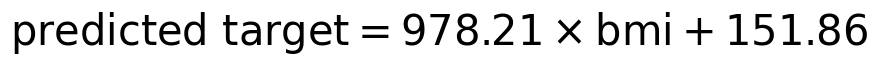

In [7]:
model.intercept_

array([151.86167557])

## 8. Predict on the test set

### What this does
```python
y_pred = model.predict(x_test)
y_pred
```

Plugs each of the 89 `bmi` values in `x_test` (data the model never saw during training) into the learned equation above, producing 89 predictions. No new learning happens here — it's pure arithmetic using the already-fitted line.

### Output
A NumPy array of shape `(89, 1)` — one predicted `target` value per test row, in the same order as `x_test`.

Note: some predictions repeat exactly (e.g. `126.81` appears more than once). Because this model uses a single straight line and only one feature, any two patients with the same `bmi` will always get the identical prediction — even if their true outcomes differ. This is a direct consequence of the model's simplicity (a hint at underfitting when only using one feature).

*(Output below is reformatted to 2 decimal places, multiple values per line, for readability — the actual `y_pred` array has full floating-point precision.)*

In [8]:
y_pred = model.predict(x_test)
y_pred

array([[134.19341098],
       [189.01822442],
       [184.80093108],
       [162.66014104],
       [126.81314764],
       [245.95168453],
       [202.72442778],
       [ 86.74886089],
       [206.94172112],
       [118.37856095],
       [196.39848777],
       [211.15901447],
       [112.05262094],
       [157.38852436],
       [106.78100426],
       [132.08476431],
       [ 88.85750756],
       [146.84529101],
       [112.05262094],
       [156.33420103],
       [121.54153096],
       [129.97611764],
       [167.93175772],
       [170.04040439],
       [181.63796108],
       [ 95.18344757],
       [120.48720762],
       [138.41070432],
       [171.09472772],
       [128.92179431],
       [137.35638099],
       [108.88965093],
       [148.95393768],
       [119.43288429],
       [139.46502766],
       [174.25769773],
       [126.81314764],
       [127.86747097],
       [158.4428477 ],
       [145.79096767],
       [132.08476431],
       [140.519351  ],
       [144.73664434],
       [176

## 9. Import evaluation metrics

### What this does
```python
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np
```

Imports functions to measure how good `y_pred` is compared to the real `y_test` values. `numpy` is imported for later use (e.g. `np.sqrt()` to get RMSE from MSE).

In [9]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

## 10. Calculate Mean Squared Error (MSE)

### What this does
```python
mse = mean_squared_error(y_test, y_pred)
mse
```

Compares all 89 predictions against the real answers, computes the difference for each row, squares each difference, then averages all 89 squared differences:

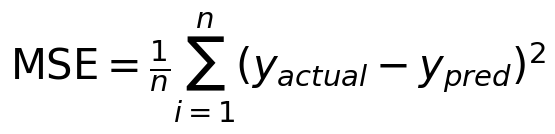

### Why square the differences?
1. **Cancels out sign** — a difference of -57 and +57 are equally wrong; without squaring they'd cancel out when averaged.
2. **Punishes large mistakes more** — a difference of 57 squared is 3271, but a difference of 8.8 squared is only 77.6. Bigger errors are penalized disproportionately.

### Interpreting the output
`MSE ≈ 3863.77`. This number is in *squared* target units, which makes it a bit hard to interpret directly — this is why MSE is often followed by taking its square root (RMSE) to bring it back to the original scale of `target`.

### Why this matters
This turns "eyeballing predictions row by row" into one concrete number. A lower MSE on the *test* set (not training set) means the model generalizes better — this is the actual, measurable way to compare models (e.g. this simple one-feature model vs. a Ridge/LASSO model using more features).

In [10]:
mse = mean_squared_error(y_test,y_pred)
mse

3863.7719143971945